In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data\stud.csv')

In [3]:
df.head(3)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There is no null values in any of the columns

In [6]:
df.duplicated().sum()

0

There is no duplicated values

In [7]:
df.dtypes

gender                         object
race_ethnicity                 object
parental_level_of_education    object
lunch                          object
test_preparation_course        object
math_score                      int64
reading_score                   int64
writing_score                   int64
dtype: object

In [8]:
categorical_colunms = [feature for feature in df.columns if df[feature].dtypes == 'O']
numerical_colunms = [feature for feature in df.columns if df[feature].dtypes != 'O']
print(categorical_colunms)
print(numerical_colunms)

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
['math_score', 'reading_score', 'writing_score']


In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [10]:
for feature in categorical_colunms:
  print(f"The unique feature for {feature}:",end=" ")
  print(df[feature].unique())

The unique feature for gender: ['female' 'male']
The unique feature for race_ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E']
The unique feature for parental_level_of_education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
The unique feature for lunch: ['standard' 'free/reduced']
The unique feature for test_preparation_course: ['none' 'completed']


In [11]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score']/3

In [12]:
df.describe()

,math_score,reading_score,writing_score,total_score,average
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770667
std,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.00000,17.000000,10.000000,27.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,58.333333
50%,66.00000,70.000000,69.000000,205.000000,68.333333
75%,77.00000,79.000000,79.000000,233.000000,77.666667
max,100.00000,100.000000,100.000000,300.000000,100.000000


In [13]:
high_maths_score = df[df['math_score'] == 100]['average'].count()
high_reading_score = df[df['reading_score'] == 100]['average'].count()
high_writing_score = df[df['writing_score'] == 100]['average'].count()
print(f"Number of students scoring 100 in maths {high_maths_score}")
print(f"Number of students scoring 100 in reading {high_reading_score}")
print(f"Number of students scoring 100 in writing {high_writing_score}")

Number of students scoring 100 in maths 7
Number of students scoring 100 in reading 17
Number of students scoring 100 in writing 14


In [14]:
low_maths_score = df[df['math_score'] <= 20]['average'].count()
low_reading_score = df[df['reading_score'] <= 20]['average'].count()
low_writing_score = df[df['writing_score'] <= 20]['average'].count()
print(f"Number of students scoring less than 20 in maths {low_maths_score}")
print(f"Number of students scoring less than 20 in reading {low_reading_score}")
print(f"Number of students scoring less than 20 in writing {low_writing_score}")

Number of students scoring less than 20 in maths 4
Number of students scoring less than 20 in reading 1
Number of students scoring less than 20 in writing 3


<Axes: xlabel='average', ylabel='Count'>

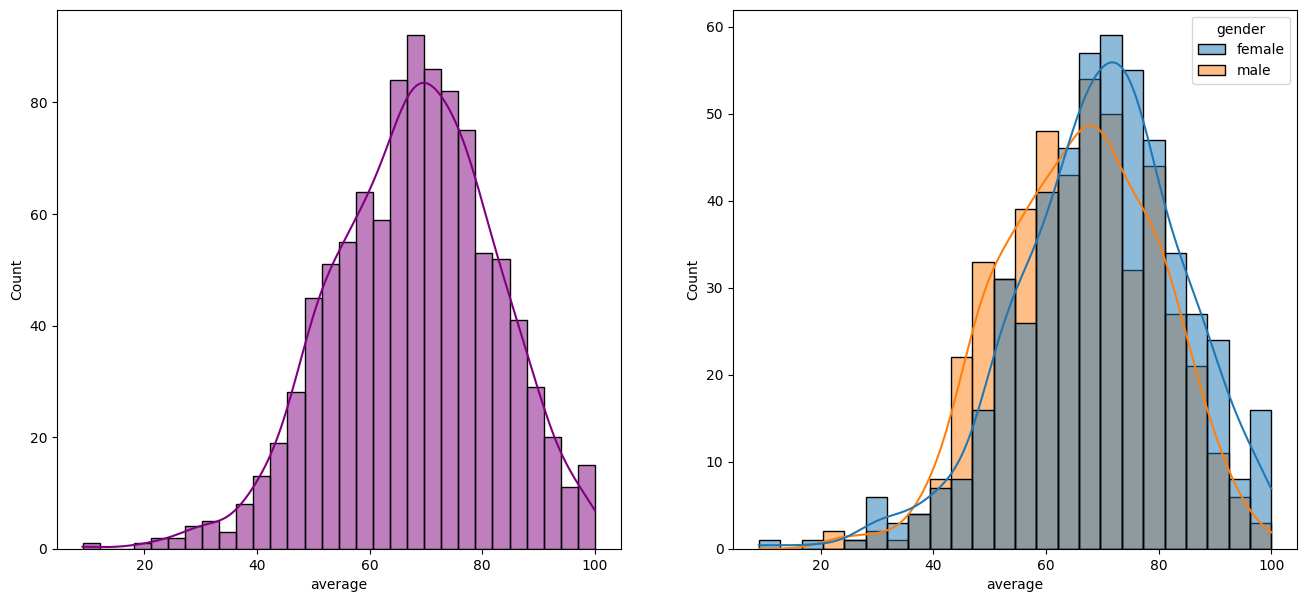

In [15]:
fig,axs = plt.subplots(1,2,figsize=(16,7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='purple')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')

### Insights 
- Female students are having more average score than Male students 

<Axes: xlabel='total_score', ylabel='Count'>

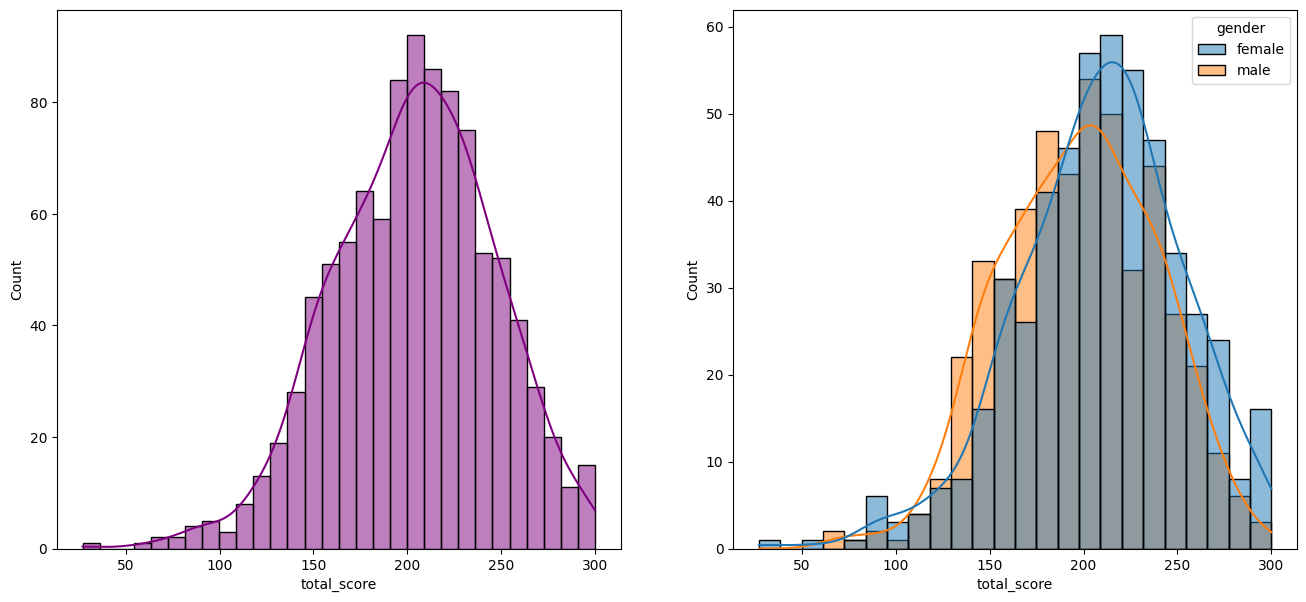

In [16]:
fig,axs = plt.subplots(1,2,figsize=(16,7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='purple')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')

### Insights  
- Female students are having more Total score than Male students 

<Axes: xlabel='average', ylabel='Count'>

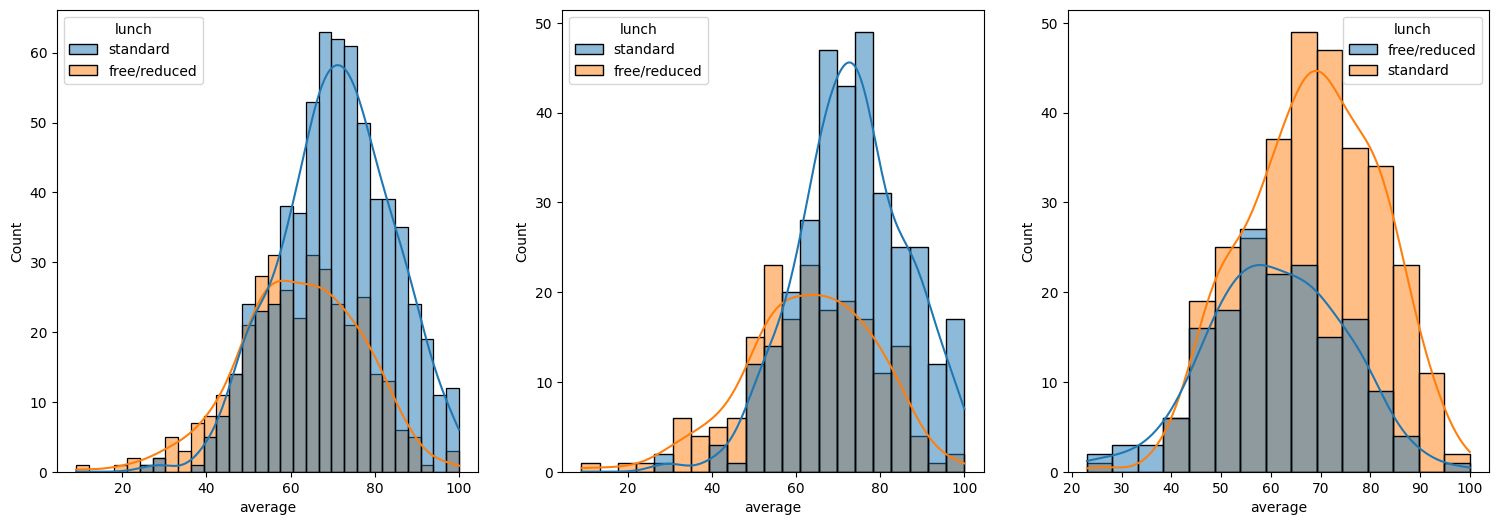

In [17]:
fig,axs = plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df['gender'] == 'female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df['gender'] == 'male'],x='average',kde=True,hue='lunch')

### Insights
- Lunch does not makes difference in female and male students average marks
- But when both male and female students are getting standard lunch there average score is high

<Axes: xlabel='average', ylabel='Count'>

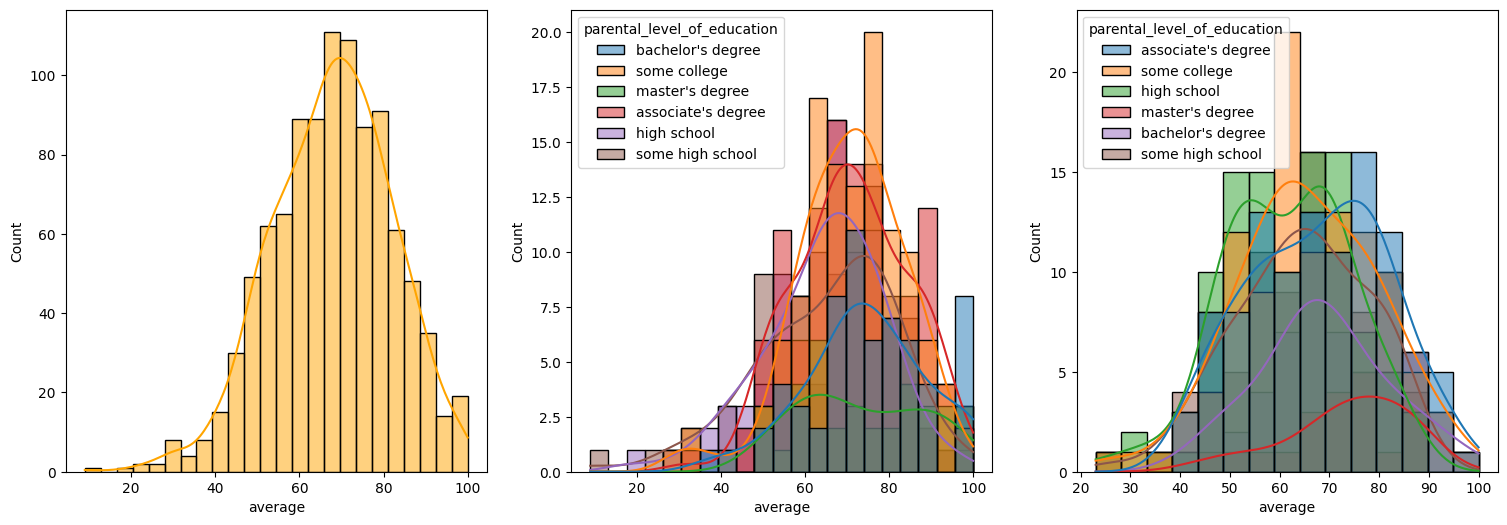

In [18]:
fig,axs = plt.subplots(1,3,figsize = (25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,color='orange')
plt.subplot(142)
sns.histplot(data=df[df['gender'] == 'female'],x='average',kde=True,hue='parental_level_of_education')
plt.subplot(143)
sns.histplot(data=df[df['gender'] == 'male'],x='average',kde=True,hue='parental_level_of_education')

# Insights 
- Basically parental level of education doesn't descides how the kids will perform
## But in this dataset as per the Graph it effects the scores of the student
### Female
- Students whose parents are having master degree are scoring less average marks then compared to others
- Students whose parents are done some college are having high average marks then compared to others
### Male
- Students whose parents are having master degree are scoring less average marks then compared to others
- But in male students almost every category are having similar average marks then compared to females

<Axes: xlabel='average', ylabel='Count'>

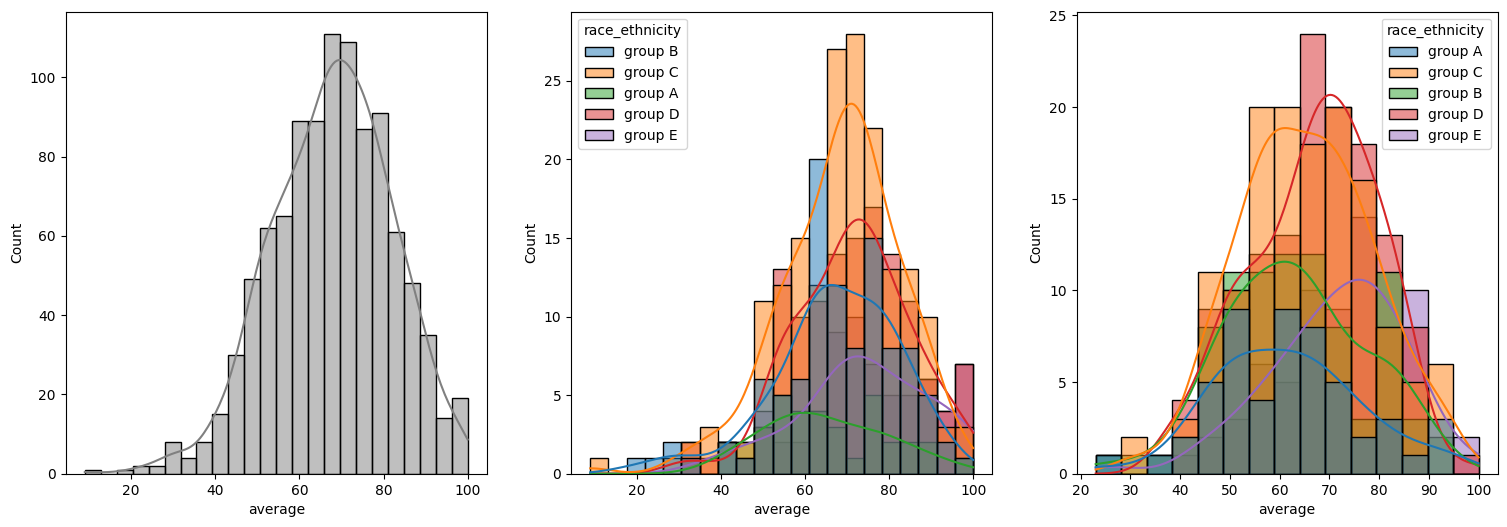

In [19]:
fig,axs = plt.subplots(1,3,figsize = (25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,color='grey')
plt.subplot(142)
sns.histplot(data=df[df['gender'] == 'female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(143)
sns.histplot(data=df[df['gender'] == 'male'],x='average',kde=True,hue='race_ethnicity')

## Insights
### Female 
-  Group A and Group E students are having very less average score compared to other groups
-  Group C students are having very high average score compared to other groups 
### Male 
-  Group A , Group B and Group E students are having very less average score compared to other groups
-  Group C and Group D students are having very high average score compared to other groups 
#### But in my personal opinion it doesn't matter from which group we are anybody can get good score 

In [22]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'average'],
      dtype='object')

<Axes: title={'center': 'Writing score'}, ylabel='writing_score'>

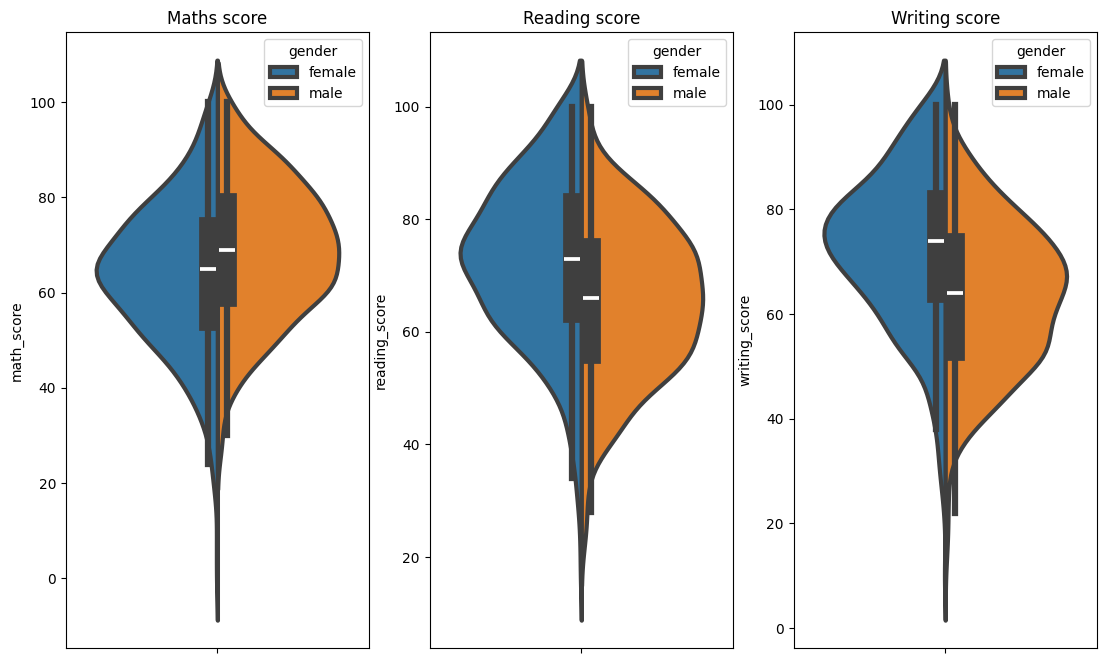

In [20]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('Maths score')
sns.violinplot(data=df,y='math_score',linewidth=3,split=True,hue="gender")
plt.subplot(1,4,2)
plt.title('Reading score')
sns.violinplot(data=df,y='reading_score',linewidth=3,split=True,hue="gender")
plt.subplot(1,4,3)
plt.title('Writing score')
sns.violinplot(data=df,y='writing_score',linewidth=3,split=True,hue="gender")

### Insights 
- Only in maths subject most of the male students are having high average compared to female , male 65 to 85 ,female 55 to 75
- In Reading subject most of the male students are having high average compared to female , male 54 to 75 ,female 60 to 85
- In Writing subject most of the male students are having high average compared to female , male 50 to 75 ,female 64 to 85


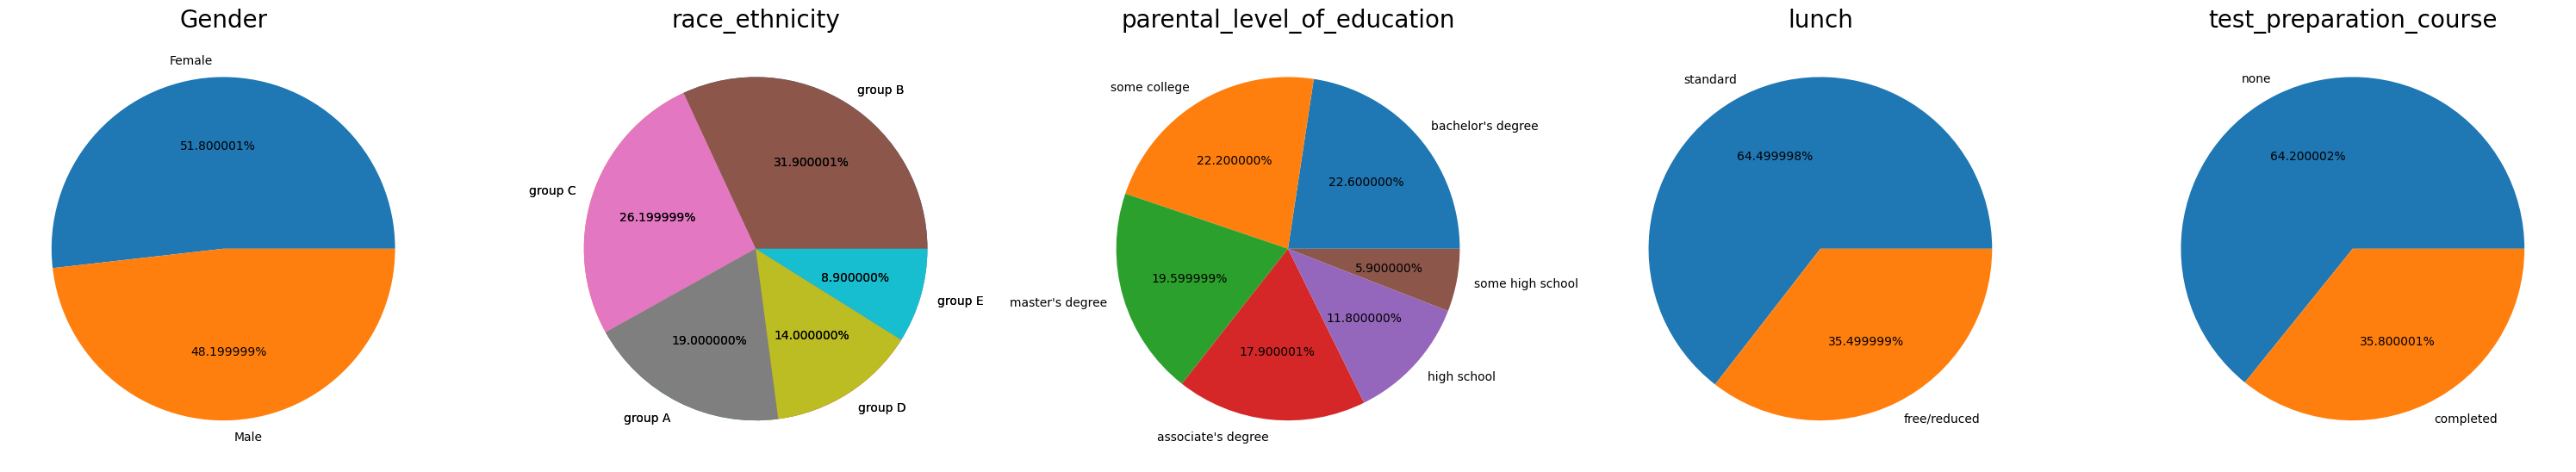

In [21]:
plt.rcParams['figure.figsize'] = (30,12)

plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female','Male'
color = ['green','blue']

plt.pie(size,labels=labels,autopct='%2f%%')
plt.title('Gender',fontsize = 20)
plt.axis('off')

plt.subplot(1,5,2)
size = df['race_ethnicity'].value_counts()
labels = 'group B', 'group C', 'group A', 'group D', 'group E'

plt.pie(size,labels=labels,autopct='%2f%%')
plt.title('Gender',fontsize = 20)
plt.axis('off')

plt.subplot(1,5,2)
size = df['race_ethnicity'].value_counts()
labels = 'group B', 'group C', 'group A', 'group D', 'group E'

plt.pie(size,labels=labels,autopct='%2f%%')
plt.title('race_ethnicity',fontsize = 20)
plt.axis('off')

plt.subplot(1,5,3)
size = df['parental_level_of_education'].value_counts()
labels = "bachelor's degree", 'some college', "master's degree","associate's degree", 'high school', 'some high school'

plt.pie(size,labels=labels,autopct='%2f%%')
plt.title('parental_level_of_education',fontsize = 20)
plt.axis('off')

plt.subplot(1,5,4)
size = df['lunch'].value_counts()
labels = 'standard', 'free/reduced'

plt.pie(size,labels=labels,autopct='%2f%%')
plt.title('lunch',fontsize = 20)
plt.axis('off')

plt.subplot(1,5,5)
size = df['test_preparation_course'].value_counts()
labels = 'none', 'completed'

plt.pie(size,labels=labels,autopct='%2f%%')
plt.title('test_preparation_course',fontsize = 20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()

## Insights
### Gender
- Almost the population of both male and female are equal 
### Race Ethinicity
- Group B and Group C people population is more compared to other groups 
- Group E population is less compared to othe groups
### Parental level of education
- Almost every level of parents are equal but the parents who did some high school are very less compared to others
### Lunch
- Almost 64% of times students are getting standard food 
### Test Preperation course
- Almost 64% of students didnt completed the test preperation course